#**PRIMER EXÁMEN DE CÁLCULO - SANTIAGO VOLIO**

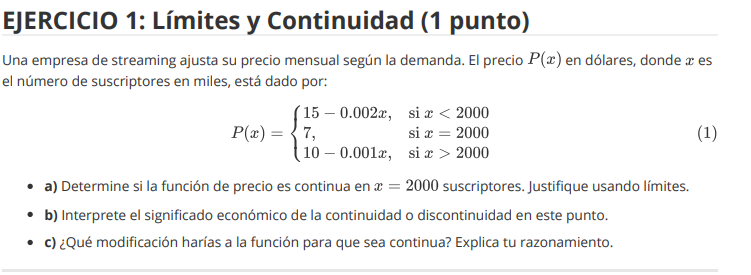

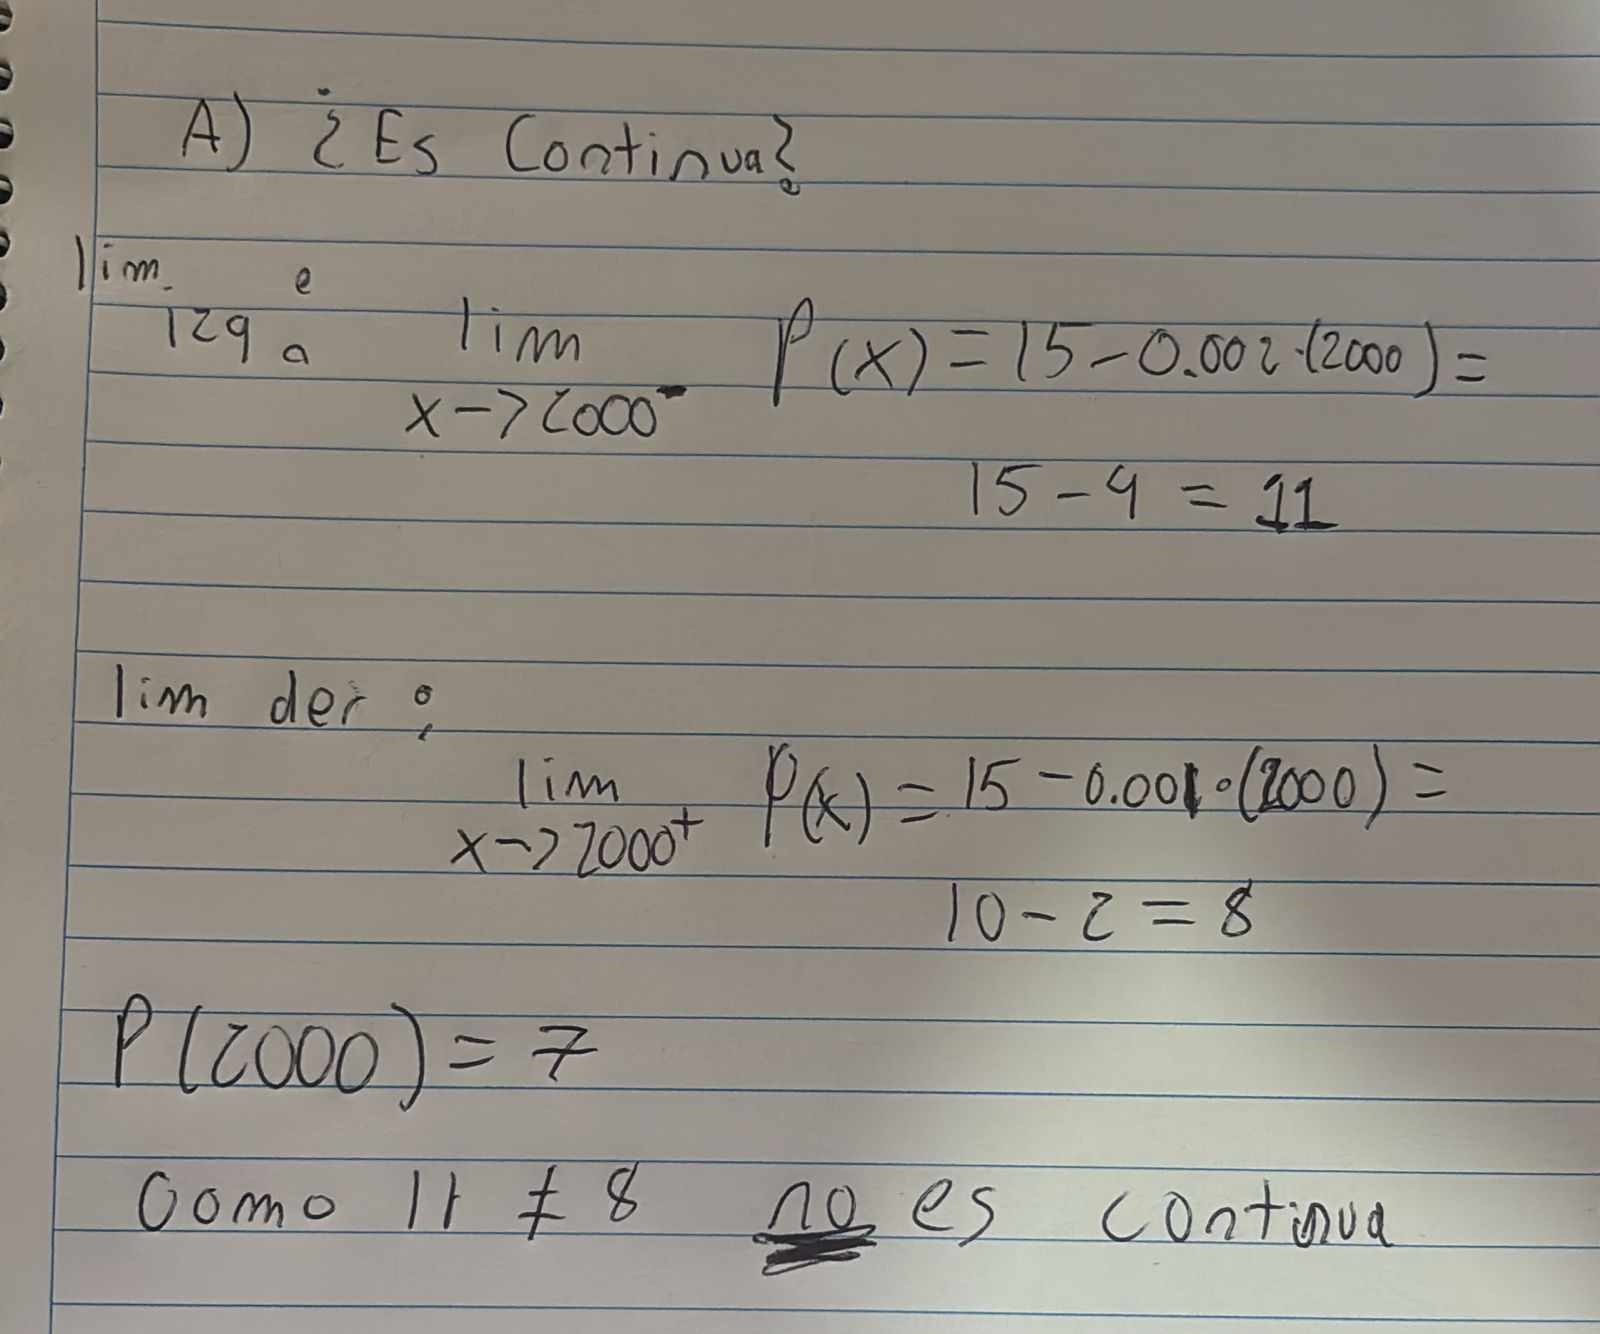

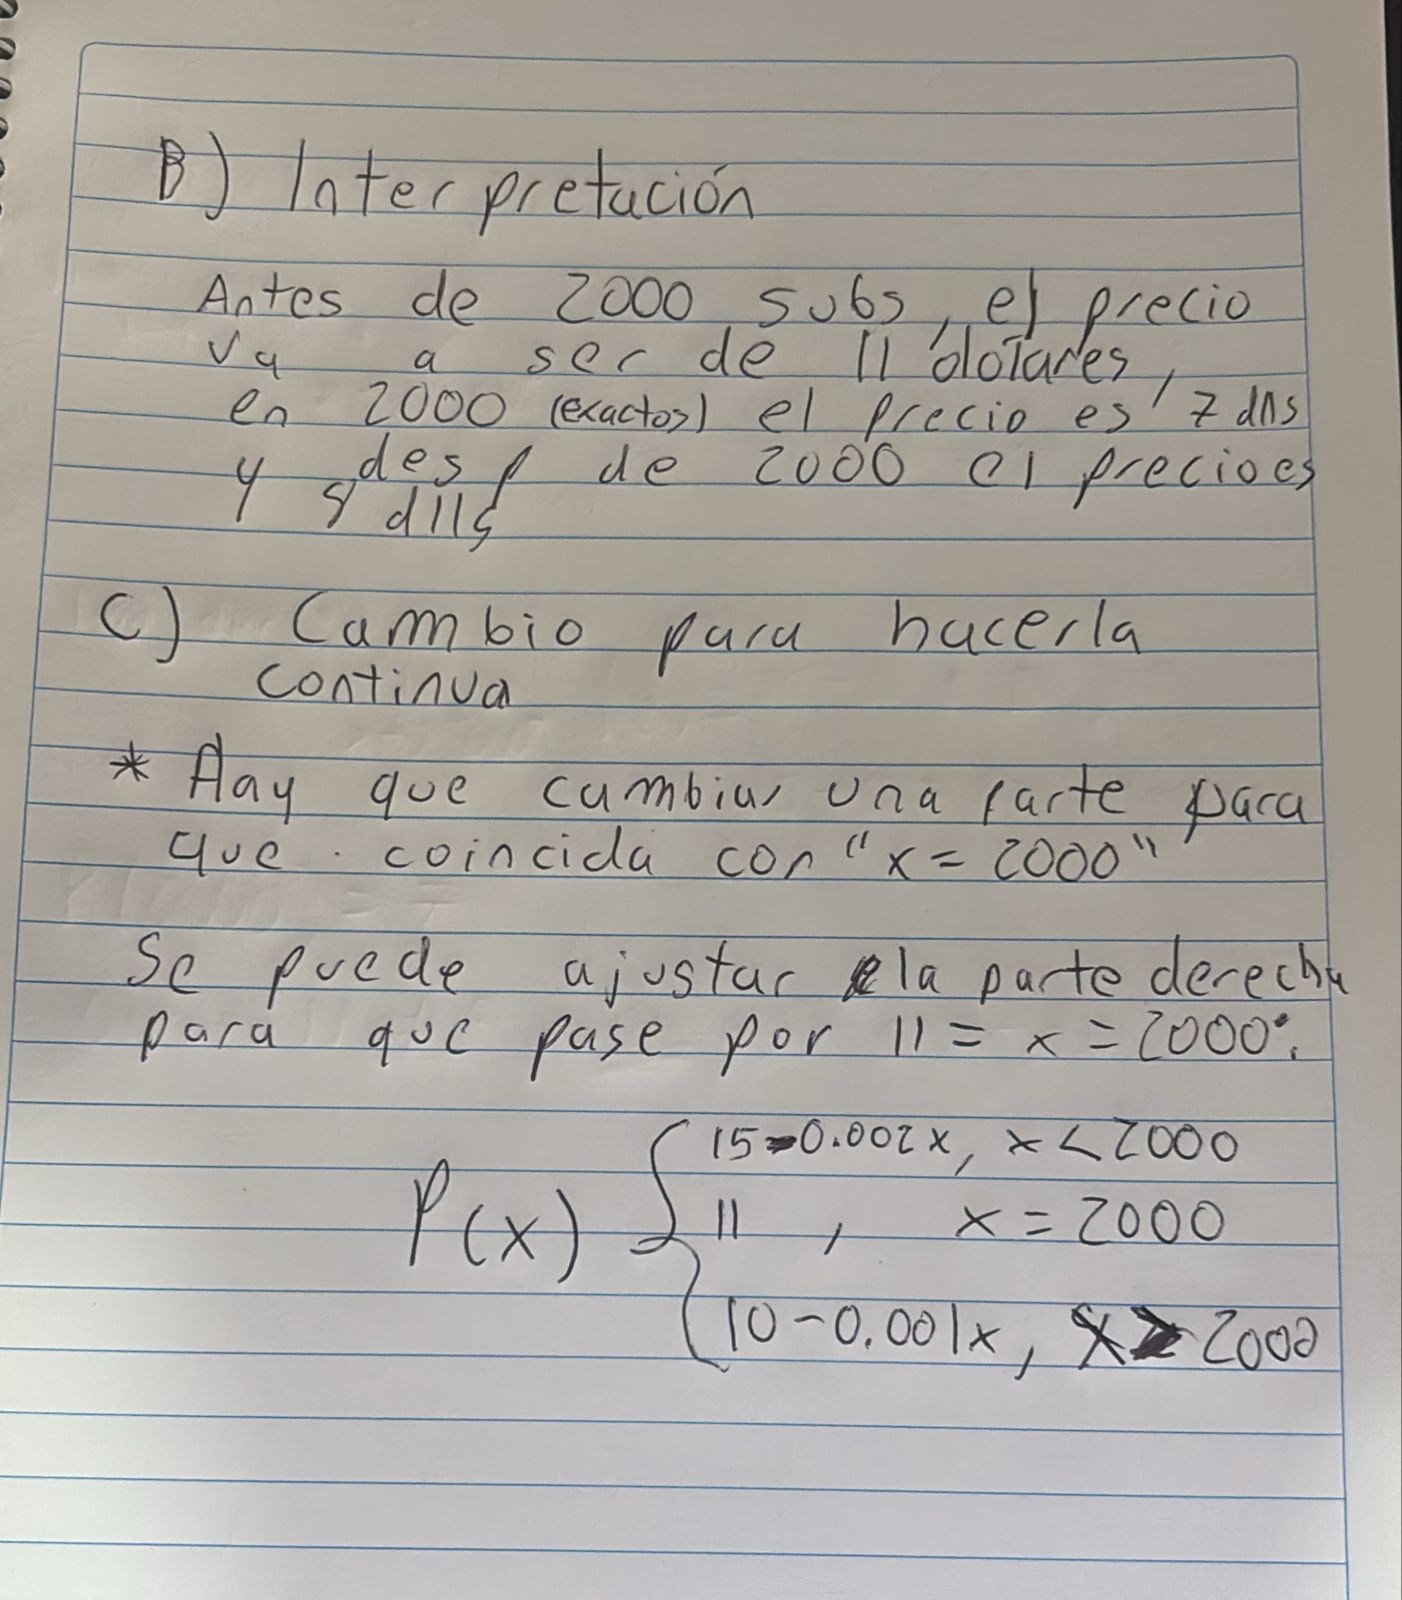

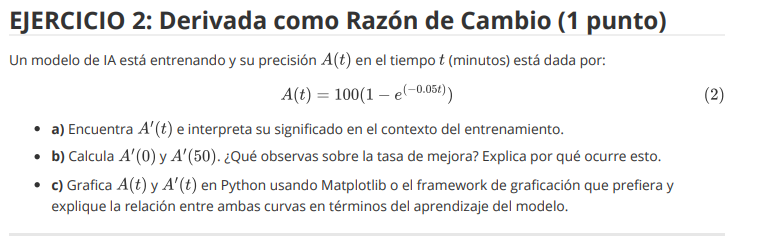

 A) Encuentra A'(t) e interpreta su significado en el contexto del entrenamiento.
-------------------------------------------------------------------------------------
A(t) = 100 - 100*exp(-0.05*t)
A'(t) = 5.0*exp(-0.05*t)
 Interpretación: A'(t) representa la velocidad con que mejora la precisión del modelo.
 Por eso, el modelo aprende de manera rapida y efectiva. Sin embargo, con el tiempo, esa velocidad de mejora tiende a disminuir.
-------------------------------------------------------------------------------------
 B) Calcula A'(0) y A'(50). ¿Qué observas sobre la tasa de mejora? Explica por qué ocurre esto.
-------------------------------------------------------------------------------------
A'(0) = 5.00000000000000
A'(50) = 0.410424993119494
 Observación: Al inicio (t=0), la tasa de mejora es alta (5.00).
A los 50 minutos, la tasa baja a 0.41.
Esto ocurre porque el modelo se acerca a su límite de aprendizaje y las mejoras son menores.
--------------------------------------------

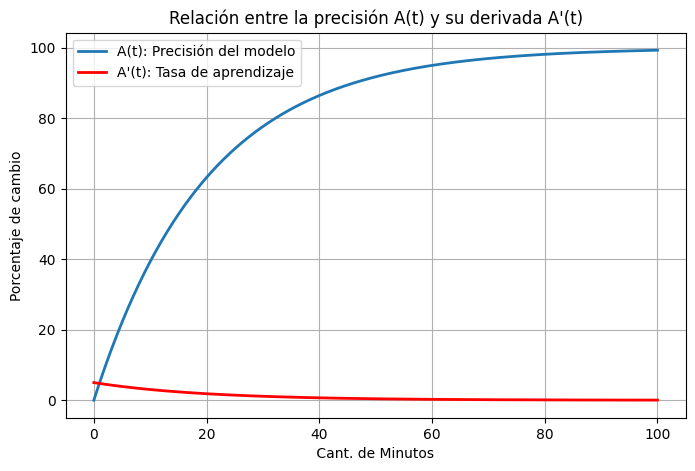

 
En la gráfica se observa que A(t) aumenta rápidamente al inicio y luego se estabiliza,
mientras que A'(t) decrece evidentemente. Esto indica que el modelo aprende más rápido
al principio y, conforme mejora, sus incrementos de precisión se vuelven más pequeños.


In [130]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# A) Encuentra A'(t) e interpreta su significado en el contexto del entrenamiento.

print(" A) Encuentra A'(t) e interpreta su significado en el contexto del entrenamiento.")

print("-" * 85)

t = sp.symbols('t', real=True)
A = 100 * (1 - sp.exp(-0.05 * t))      # Función de precisión A(t)
A_deriv = sp.diff(A, t).simplify()     # Derivada A'(t)

print("A(t) =", A)
print("A'(t) =", A_deriv)
print(" Interpretación: A'(t) representa la velocidad con que mejora la precisión del modelo.")
print(" Por eso, el modelo aprende de manera rapida y efectiva. Sin embargo, con el tiempo, esa velocidad de mejora tiende a disminuir.")

# B) Calcula A'(0) y A'(50). ¿Qué observas sobre la tasa de mejora? Explica por qué ocurre esto.

print("-" * 85)
print(" B) Calcula A'(0) y A'(50). ¿Qué observas sobre la tasa de mejora? Explica por qué ocurre esto.")
print("-" * 85)

A_deriv0 = sp.N(A_deriv.subs(t, 0))
A_deriv1 = sp.N(A_deriv.subs(t, 50))

print("A'(0) =", A_deriv0)
print("A'(50) =", A_deriv1)
print(f" Observación: Al inicio (t=0), la tasa de mejora es alta ({A_deriv0:.2f}).")
print(f"A los 50 minutos, la tasa baja a {A_deriv1:.2f}.")
print("Esto ocurre porque el modelo se acerca a su límite de aprendizaje y las mejoras son menores.")


# C) Grafica A(t) y A'(t) en Python usando Matplotlib o el framework de graficación que prefiera
# y explique la relación entre ambas curvas en términos del aprendizaje del modelo.

print("-" * 93)

print(" C) Grafica A(t) y A'(t) en Python usando Matplotlib o el framework de graficación que prefiera y explique la relación entre ambas curvas en términos del aprendizaje del modelo. ")

print("-" * 185)

t_vals = np.linspace(0, 100, 400)
A_func = sp.lambdify(t, A)
A_deriv_func = sp.lambdify(t, A_deriv)
A_vals = A_func(t_vals)
A_deriv_vals = A_deriv_func(t_vals)
plt.figure(figsize=(8, 5))
plt.plot(t_vals, A_vals, label="A(t): Precisión del modelo", linewidth=2)
plt.plot(t_vals, A_deriv_vals, label="A'(t): Tasa de aprendizaje", linewidth=2, color = 'red')
plt.title("Relación entre la precisión A(t) y su derivada A'(t)")
plt.xlabel(" Cant. de Minutos ")
plt.ylabel("Porcentaje de cambio")
plt.grid(True)
plt.legend()
plt.show()

print(" ")
print("En la gráfica se observa que A(t) aumenta rápidamente al inicio y luego se estabiliza,")
print("mientras que A'(t) decrece evidentemente. Esto indica que el modelo aprende más rápido")
print("al principio y, conforme mejora, sus incrementos de precisión se vuelven más pequeños.")

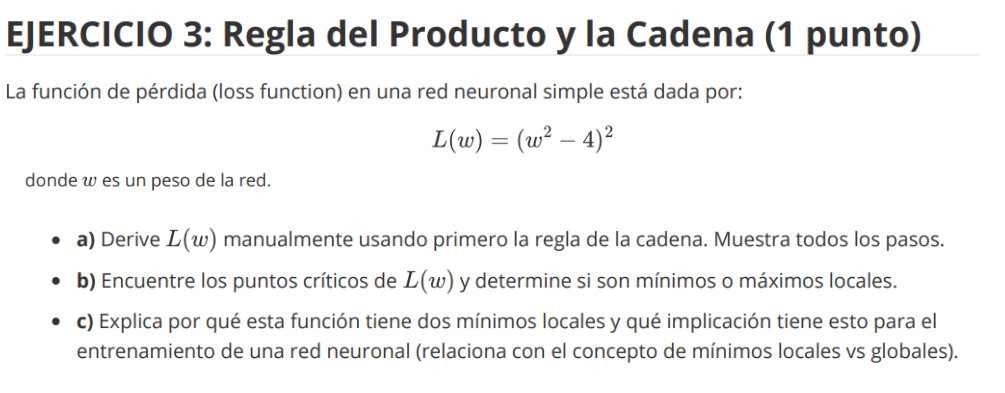

In [127]:
# L(w) = (w^2 - 4)^2

import sympy as sp


w = sp.Symbol('w', real=True)
L = (w**2 - 4)**2


# A) Derivar L(w) manualmente usando la regla de la cadena

print(" ")
print("A) Derivación de L(w) usando la regla de la cadena.")
print(" ")

# Pasos solicitados:
print(" ")
print("Sea u = w^2 - 4 -> L = u^2")
print("dL/dw = 2u * du/dw = 2(w^2 - 4) * 2w = 4w(w^2 - 4)")
L_prime = sp.diff(L, w)
print("L(w) =", L)
print("L'(w) =", L_prime)
print(" ")
print("Se deriva el cuadrado exterior (2·u) y luego el interior (2w).")
print("Por tanto, L'(w) = 4w(w² - 4).")
print(" ")

# B) Puntos críticos y clasificación (mínimo/máximo)

print(" ")
print("B) Encuentra los puntos críticos y determina su tipo.\n")
print(" ")

criticos = sp.solve(sp.Eq(L_prime, 0), w)
print("Puntos críticos:", criticos)
print(" ")
# Segunda derivada
L_double = sp.diff(L_prime, w)
print("L''(w) =", L_double)

# Clasificar cada punto crítico
for c in criticos:
    segunda = L_double.subs(w, c)
    tipo = "mínimo local" if segunda > 0 else "máximo local" if segunda < 0 else "punto de inflexión"
    # Convert SymPy object to float for formatting
    print(f"w = {float(c):>4},  L''(w) = {float(segunda):>4},  -> {tipo}")

print(" ")
print("Conclusión:")
print(" ")
print("Hay mínimos locales en w = -2 y w = 2 (donde la función se aplana en los valles).")
print("En w = 0 hay un máximo local, ya que L''(0) < 0.")


# C) Explicación (mínimos locales)

print(" ")
print("C) Explica por qué esta función tiene dos mínimos locales y su implicación en el entrenamiento.")
print(" ")

print("La función L(w) tiene dos mínimos locales en w = -2 y w = 2, ambos con el mismo valor L = 0.")
print("Estos son también mínimos globales, ya que no existen valores menores posibles.")
print("Durante el entrenamiento de una red neuronal, el descenso de gradiente podría converger a cualquiera de ellos,")
print("dependiendo del punto inicial (simetría de la función).")
print("Este fenómeno refleja cómo los modelos pueden caer en distintos mínimos igualmente buenos,")
print("aunque en funciones más complejas podrían existir mínimos locales menos favorables.")

 
A) Derivación de L(w) usando la regla de la cadena.
 
 
Sea u = w^2 - 4 -> L = u^2
dL/dw = 2u * du/dw = 2(w^2 - 4) * 2w = 4w(w^2 - 4)
L(w) = (w**2 - 4)**2
L'(w) = 4*w*(w**2 - 4)
 
Se deriva el cuadrado exterior (2·u) y luego el interior (2w).
Por tanto, L'(w) = 4w(w² - 4).
 
 
B) Encuentra los puntos críticos y determina su tipo.

 
Puntos críticos: [-2, 0, 2]
 
L''(w) = 12*w**2 - 16
w = -2.0,  L''(w) = 32.0,  -> mínimo local
w =  0.0,  L''(w) = -16.0,  -> máximo local
w =  2.0,  L''(w) = 32.0,  -> mínimo local
 
Conclusión:
 
Hay mínimos locales en w = -2 y w = 2 (donde la función se aplana en los valles).
En w = 0 hay un máximo local, ya que L''(0) < 0.
 
C) Explica por qué esta función tiene dos mínimos locales y su implicación en el entrenamiento.
 
La función L(w) tiene dos mínimos locales en w = -2 y w = 2, ambos con el mismo valor L = 0.
Estos son también mínimos globales, ya que no existen valores menores posibles.
Durante el entrenamiento de una red neuronal, el descenso de 

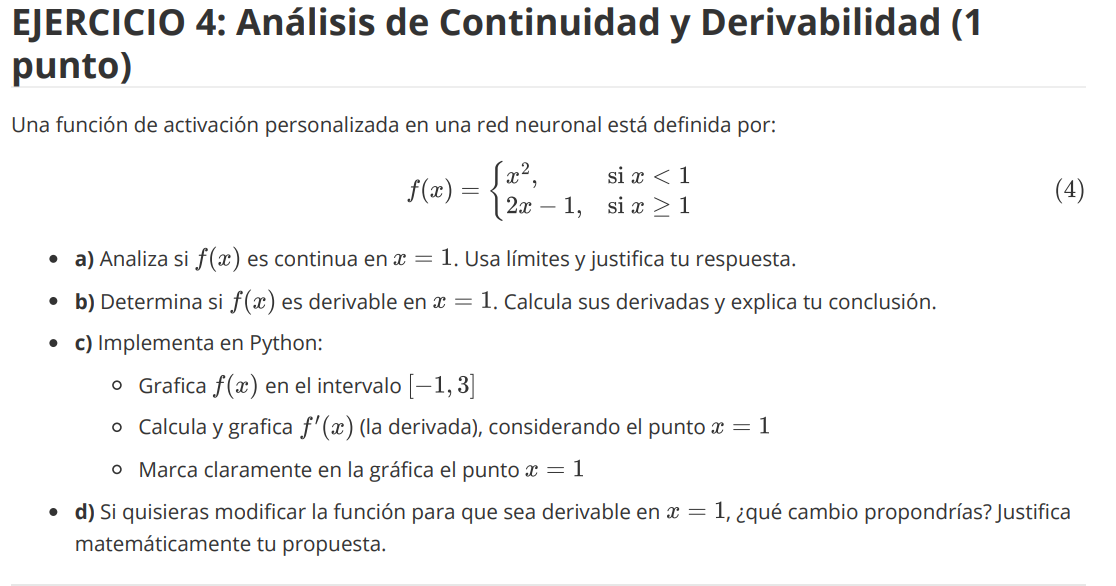

A) Analiza si f(x) es continua en x = 1. Usa límites y justifica tu respuesta.

Límite por la izquierda  x -> 1- : 1
Límite por la derecha    x -> 1+ : 1
Valor de la función en x=1       : 1.00000000000000
 la función es continua en x=1 porque límite izquierdo = límite derecho = f(1). 
 
B) Determina si f(x) es derivable en x = 1. Calcula sus derivadas y explica tu conclusión. 
 
Derivada por la izquierda  (x<1): f'_-(x) =  2*x   ->  f'_-(1) = 2.00000000000000
Derivada por la derecha   (x≥1): f'_+(x) =  2   ->  f'_+(1) = 2.00000000000000
 Conclusión: f(x) es derivable en x=1 porque las derivadas laterales coinciden y f es continua.
 
C) Implementar en Python:
 
   • Grafica f(x) en el intervalo [−1, 3]
   • Calcula y grafica f′(x) (la derivada), considerando el punto x = 1
   • Marca claramente en la gráfica el punto x = 1



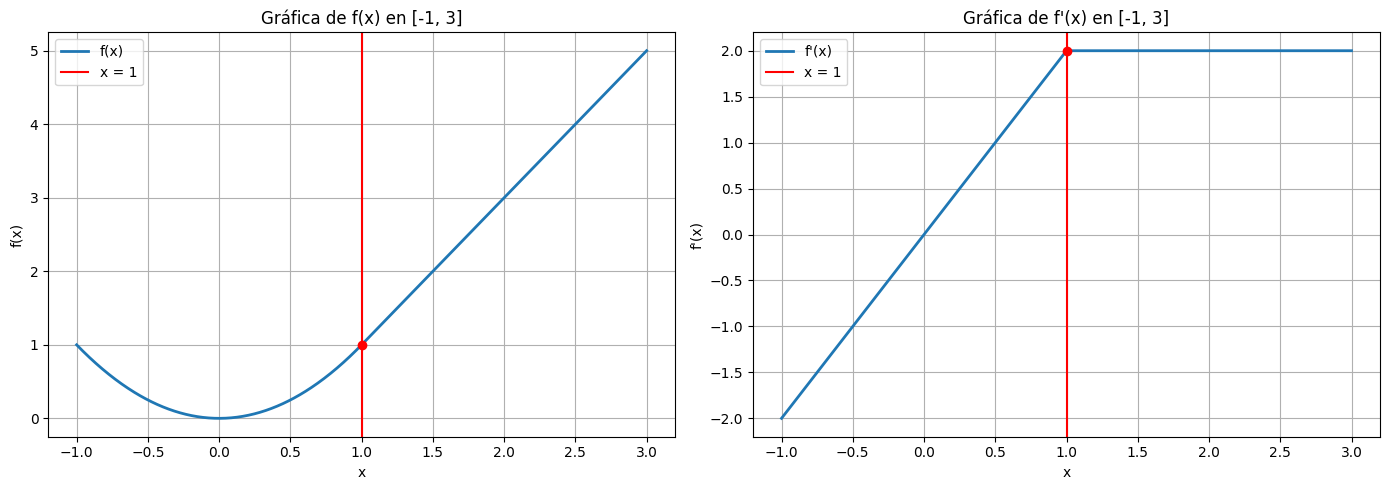

 
Los gráficos interpretan que f(x) es continua en x=1 y su derivada no presenta salto en x=1. 
 
 
D) Si quisieras modificar la función para que sea derivable en x = 1, ¿qué cambio propondrías? Justifica matemáticamente tu propuesta. 
 
La función dada ya es derivable en x=1, por lo tanto: 
Si el segundo tramo fuera otra función, las condiciones para que sea derivable en x=1 deberían ser: 
   1) Continuidad:  límite x→1- de x^2 (=1) debe igualar f(1) -> a + b = 1 
   2) Igualdad de derivadas laterales:  (x^2)' {x=1} = 2 debe igualar f'(x)=a -> a = 2
De la igualdad de derivadas laterales se obtiene a=2 y con la continuidad se obtiene b = -1. Es decir, la función en sí.


In [115]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt


# A) Analiza si f(x) es continua en x = 1. Usa límites y justifica tu respuesta.

print("A) Analiza si f(x) es continua en x = 1. Usa límites y justifica tu respuesta.\n")

x = sp.symbols('x', real=True)
f = sp.Piecewise((x**2, x < 1), (2*x - 1, True))

lim_izq = sp.limit(f, x, 1, dir='-')
lim_der = sp.limit(f, x, 1, dir='+')
f_en_1  = round(sp.N(f.subs(x, 1)), 2)

print("Límite por la izquierda  x -> 1- :", lim_izq)
print("Límite por la derecha    x -> 1+ :", lim_der)
print("Valor de la función en x=1       :", f_en_1)

if sp.simplify(lim_izq - lim_der) == 0 and sp.simplify(lim_izq - f_en_1) == 0:
    print(" la función es continua en x=1 porque límite izquierdo = límite derecho = f(1). ")
else:
    print(" f(x) NO es continua en x=1.")


# B) Determina si f(x) es derivable en x = 1. Calcula sus derivadas y explica tu conclusión.

print(" ")
print("B) Determina si f(x) es derivable en x = 1. Calcula sus derivadas y explica tu conclusión. ")
print(" ")

f_tramo1 = x**2
f_tramo2 = 2*x - 1
f1 = sp.diff(f_tramo1, x)  # para x < 1
f2 = sp.diff(f_tramo2, x)  # para x ≥ 1

f1_en_1 = sp.N(f1.subs(x, 1))
f2_en_1 = sp.N(f2.subs(x, 1))

print("Derivada por la izquierda  (x<1): f'_-(x) = ", f1, "  ->  f'_-(1) =", f1_en_1)
print("Derivada por la derecha   (x≥1): f'_+(x) = ", f2, "  ->  f'_+(1) =", f2_en_1)

if sp.simplify(f1_en_1 - f2_en_1) == 0 and sp.simplify(lim_izq - f_en_1) == 0:
    print(" Conclusión: f(x) es derivable en x=1 porque las derivadas laterales coinciden y f es continua.")
else:
    print(" Conclusión: f(x) NO es derivable en x=1 (alguna derivada lateral difiere o no hay continuidad).")


# C) Implementa en Python:
#    • Grafica f(x) en el intervalo [−1, 3]
#    • Calcula y grafica f′(x) (la derivada), considerando el punto x = 1
#    • Marca claramente en la gráfica el punto x = 1

print(" ")
print("C) Implementar en Python:")
print(" ")
print("   • Grafica f(x) en el intervalo [−1, 3]")
print("   • Calcula y grafica f′(x) (la derivada), considerando el punto x = 1")
print("   • Marca claramente en la gráfica el punto x = 1\n")

f_l = sp.lambdify(x, f, "numpy")

def fprima3 (xx):
    xx = np.asarray(xx)
    out = np.empty_like(xx, dtype=float)
    mask = xx < 1
    out[mask] = 2*xx[mask]
    out[~mask] = 2.0
    return out

x_vals = np.linspace(-1, 3, 800)
y_vals = f_l(x_vals)
yp_vals = fprima3(x_vals)

# Gráfica de f(x) y f'(x)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(x_vals, y_vals, linewidth=2, label="f(x)")
axes[0].axvline(1, linestyle="-", color='red', label='x = 1')
axes[0].scatter([1], [float(f_en_1)], zorder=5, color='red')
axes[0].set_title("Gráfica de f(x) en [-1, 3]")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].legend()
axes[0].grid(True)
axes[1].plot(x_vals, yp_vals, linewidth=2, label="f'(x)")
axes[1].axvline(1, linestyle="-", color='red', label='x = 1')
axes[1].scatter([1], [float(f2_en_1)], zorder=5, color='red')
axes[1].set_title("Gráfica de f'(x) en [-1, 3]")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f'(x)")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()
print(" ")
print("Los gráficos interpretan que f(x) es continua en x=1 y su derivada no presenta salto en x=1. ")
print(" ")

# D) Si quisieras modificar la función para que sea derivable en x = 1, ¿qué cambio propondrías?
#    Justifica matemáticamente tu propuesta.

print(" ")
print("D) Si quisieras modificar la función para que sea derivable en x = 1, ¿qué cambio propondrías? Justifica matemáticamente tu propuesta. ")
print(" ")
print("La función dada ya es derivable en x=1, por lo tanto: ")
print("Si el segundo tramo fuera otra función, las condiciones para que sea derivable en x=1 deberían ser: ")
print("   1) Continuidad:  límite x→1- de x^2 (=1) debe igualar f(1) -> a + b = 1 ")
print("   2) Igualdad de derivadas laterales:  (x^2)' {x=1} = 2 debe igualar f'(x)=a -> a = 2")
print("De la igualdad de derivadas laterales se obtiene a=2 y con la continuidad se obtiene b = -1. Es decir, la función en sí.")

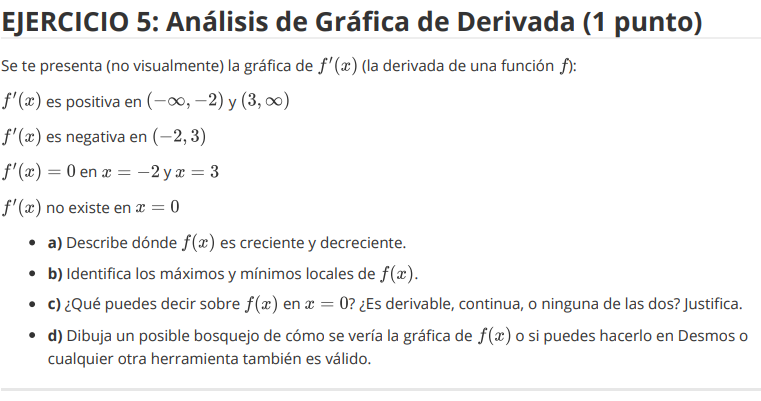

 
A) Describe dónde f(x) es creciente y decreciente. 
 
f(x) es creciente en (-∞, -2) y (3, ∞).
f(x) decrece en (-2, 3).
 
 Esto se debe a que cuando f'(x) > 0 quiere decir que habrá crecimiento, pero su derivada alterna ( f'(x) < 0 ) implica decrecimiento. 
 
 
B) Identifica los máximos y mínimos locales de f(x). 
 
Máximo local en x = -2 (f' cambia de + a −). 
Mínimo local en x = 3  (f' cambia de − a +). 
Los máximos y mínimos locales ocurren donde f'(x) cambia de signo
 
 
C) ¿Qué puedes decir sobre f(x) en x = 0? ¿Es derivable, continua, o ninguna de las dos? Justifica. 
 
En x = 0, f(x) no existe, porque la función no es derivable en x = 0.
No se informa una discontinuidad en f, con los datos dados, se concluye que f es continua pero no se puede derivar en x = 0. 
 
 
D) Dibuja un posible bosquejo de cómo se vería la gráfica de f(x): 
 


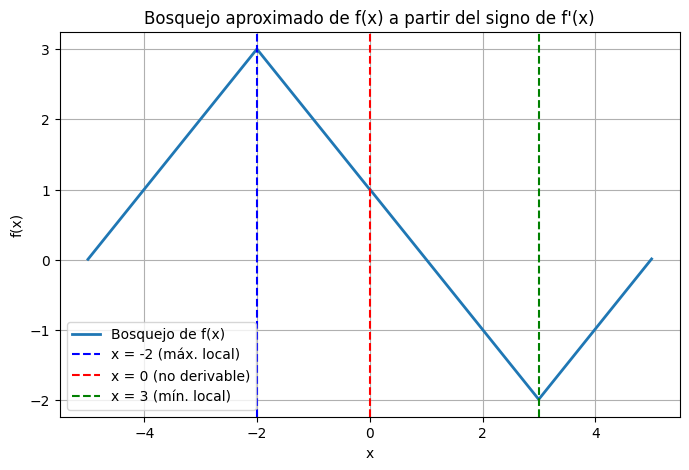

 
Interpretación del grafico:
 
f crece en (-∞, -2), alcanza un máximo local en x = -2, decrece en (-2, 3) con una punta en x = 0,
y alcanza un mínimo local en x = 3; luego vuelve a crecer en (3, ∞).


In [131]:
# Funciones derivadas del ejercicio para identificar

#   f'(x) > 0 en (-∞, -2) y (3, ∞)
#   f'(x) < 0 en (-2, 3)
#   f'(x) = 0 en x = -2 y x = 3
#   f'(x) no existe en x = 0

import numpy as np
import matplotlib.pyplot as plt


# Utilidades para el bosquejo del final

def fprima_signo(x):
    """Signo de f'(x) acorde al enunciado.
       Devuelve 1 si f'(x)>0, -1 si f'(x)<0, 0 en {-2,3}, NaN en 0."""
    y = np.zeros_like(x, dtype=float)
    for i, xi in enumerate(x):
        if xi < -2:
            y[i] = 1.0         # positiva
        elif -2 < xi < 0:
            y[i] = -1.0        # negativa
        elif xi == 0:
            y[i] = np.nan      # no existe
        elif 0 < xi < 3:
            y[i] = -1.0        # negativa
        elif xi > 3:
            y[i] = 1.0         # positiva
        else:  # xi == -2 o xi == 3
            y[i] = 0.0         # cero
    return y

# Ejes para el gráfico
x_vals = np.linspace(-5, 5, 2001)
fp_vals = fprima_signo(x_vals)
dx = x_vals[1] - x_vals[0]
fp_vals_for_int = np.nan_to_num(fp_vals, nan=0.0)  # ignoramos el punto x=0 en la integral
f_vals = np.cumsum(fp_vals_for_int) * dx           # bosquejo (constante de integración implícita = 0)

# A) Describe dónde f(x) es creciente y decreciente.

print(" ")
print("A) Describe dónde f(x) es creciente y decreciente. ")
print(" ")
print("f(x) es creciente en (-∞, -2) y (3, ∞).")
print("f(x) decrece en (-2, 3).")
print(" ")
print(" Esto se debe a que cuando f'(x) > 0 quiere decir que habrá crecimiento, pero su derivada alterna ( f'(x) < 0 ) implica decrecimiento. ")
print(" ")

## B) Identifica los máximos y mínimos locales de f(x).

print(" ")
print("B) Identifica los máximos y mínimos locales de f(x). ")
print(" ")
print("Máximo local en x = -2 (f' cambia de + a −). ")
print("Mínimo local en x = 3  (f' cambia de − a +). ")
print("Los máximos y mínimos locales ocurren donde f'(x) cambia de signo")
print(" ")

# C) ¿Qué puedes decir sobre f(x) en x = 0? ¿Es derivable, continua, o ninguna de las dos? Justifica.

print(" ")
print("C) ¿Qué puedes decir sobre f(x) en x = 0? ¿Es derivable, continua, o ninguna de las dos? Justifica. ")
print(" ")
print("En x = 0, f(x) no existe, porque la función no es derivable en x = 0.")
print("No se informa una discontinuidad en f, con los datos dados, se concluye que f es continua pero no se puede derivar en x = 0. ")
print(" ")

# D) Dibuja un posible bosquejo de cómo se vería la gráfica de f(x).

print(" ")
print("D) Dibuja un posible bosquejo de cómo se vería la gráfica de f(x): ")
print(" ")
plt.figure(figsize=(8, 5))
plt.plot(x_vals, f_vals, linewidth=2, label="Bosquejo de f(x)")
plt.axvline(-2, linestyle="--", color = 'blue', label="x = -2 (máx. local)")
plt.axvline(0,  linestyle="--", color = 'red', label="x = 0 (no derivable)")
plt.axvline(3,  linestyle="--",color = 'green', label="x = 3 (mín. local)")
plt.title("Bosquejo aproximado de f(x) a partir del signo de f'(x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()
print(" ")
print("Interpretación del grafico:")
print(" ")
print("f crece en (-∞, -2), alcanza un máximo local en x = -2, decrece en (-2, 3) con una punta en x = 0,")
print("y alcanza un mínimo local en x = 3; luego vuelve a crecer en (3, ∞).")

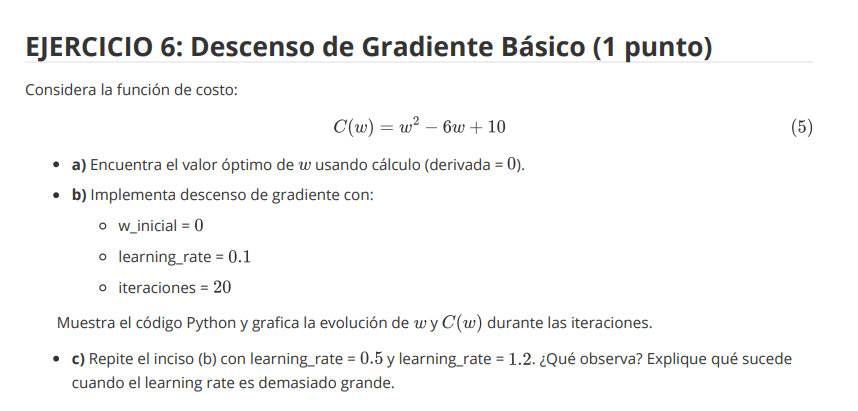


 
 A) Encuentra el valor óptimo de w usando cálculo (derivada=0)
 
C(w) = w**2 - 6*w + 10
C'(w) = 2*w - 6
Óptimo: w* = 3.0000,  C(w*) = 1.0000

 
B) Descenso de gradiente con w_inicial=0, lr=0.1, iter=20.

 
w_final = 2.965412,  C(w_final) = 1.001196,  iteraciones = 20
 
Observación: con lr=0.1 la secuencia {w_k} converge monótonamente hacia w*=3 (mínimo global de la cuadrática).

 
C) Comparación de tasas de aprendizaje: lr=0.5 y lr=1.2.

 
lr=0.5: w_final = 3.000000,  C(w_final) = 1.000000
lr=1.2: w_final = -2507.047663,  C(w_final) = 6300340.269320


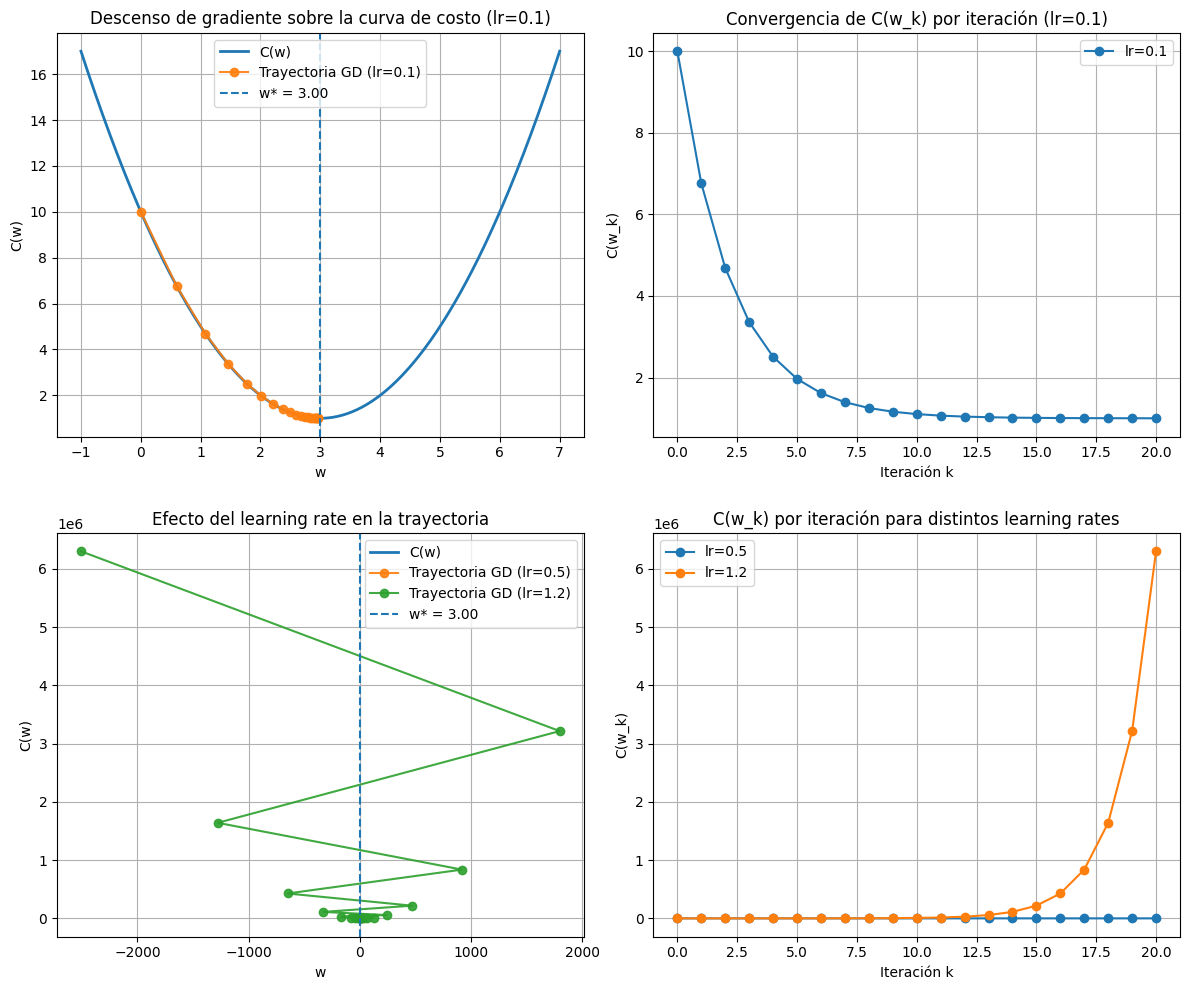

 
Explicación:
- Con lr=0.5, la convergencia es más rápida que con 0.1, aún estable para esta función convexa.
- Con lr=1.2, los pasos son demasiado grandes: la secuencia oscila y puede divergir o tardar mucho en estabilizarse.
  En general, un learning rate excesivo hace que los saltos crucen el valle y reboten, impidiendo la convergencia.


In [138]:
#Usé un tutorial de youtube sobre plotting en matplotlib para este ejercicio, se utilizó un grafico no visto en clase https://youtu.be/XFZRVnP-MTU?si=2TDl-NtuMp72FZCd
# C(w) = w^2 - 6w + 10

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

w = sp.Symbol('w', real=True)
C_sym = w**2 - 6*w + 10
dC_sym = sp.diff(C_sym, w)

C = sp.lambdify(w, C_sym, "numpy")
dC = sp.lambdify(w, dC_sym, "numpy")

# A) Encuentra el valor óptimo de w usando cálculo (derivada=0)

print(" ")
print(" A) Encuentra el valor óptimo de w usando cálculo (derivada=0)")
print(" ")

criticos = sp.solve(sp.Eq(dC_sym, 0), w)
w_opt = float(criticos[0])  # hay un único mínimo para esta cuadrática
print(f"C(w) = {C_sym}")
print(f"C'(w) = {dC_sym}")
print(f"Óptimo: w* = {w_opt:.4f},  C(w*) = {C(w_opt):.4f}\n")



# B) Implementa descenso de gradiente y grafica evolución
#    w_inicial = 0, learning_rate = 0.1, iteraciones = 20

print(" ")
print("B) Descenso de gradiente con w_inicial=0, lr=0.1, iter=20.\n")
print(" ")

def gradient_descent(w0, lr, iters):
    w_hist = [float(w0)]
    for k in range(iters):
        g = dC(w_hist[-1])
        w_new = w_hist[-1] - lr * g
        w_hist.append(w_new)
    return np.array(w_hist, dtype=float)

w0 = 0.0
lr = 0.1
iters = 20

traj = gradient_descent(w0, lr, iters)
print(f"w_final = {traj[-1]:.6f},  C(w_final) = {C(traj[-1]):.6f},  iteraciones = {traj.size-1}")

# Trayectoria sobre la curva de costo
w_axis = np.linspace(-1, 7, 400)
k = np.arange(traj.size)


# Observación breve
print(" ")
print("Observación: con lr=0.1 la secuencia {w_k} converge monótonamente hacia w*=3 (mínimo global de la cuadrática).\n")

# C) Repite con lr=0.5 y lr=1.2. ¿Qué observa?
print(" ")
print("C) Comparación de tasas de aprendizaje: lr=0.5 y lr=1.2.\n")
print(" ")
lrs = [0.5, 1.2]
trajs = [gradient_descent(w0, alpha, iters) for alpha in lrs]

for alpha, tr in zip(lrs, trajs):
    print(f"lr={alpha}: w_final = {tr[-1]:.6f},  C(w_final) = {C(tr[-1]):.6f}")

#Gráfica (subplots 2x2) https://youtu.be/XFZRVnP-MTU?si=vyt1lb6iKn8gyErC

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Descenso de gradiente
axes[0, 0].plot(w_axis, C(w_axis), label="C(w)", linewidth=2)
axes[0, 0].plot(traj, C(traj), "o-", label=f"Trayectoria GD (lr={lr})", alpha=0.9)
axes[0, 0].axvline(w_opt, linestyle="--", label=f"w* = {w_opt:.2f}")
axes[0, 0].set_title("Descenso de gradiente sobre la curva de costo (lr=0.1)")
axes[0, 0].set_xlabel("w"); axes[0, 0].set_ylabel("C(w)")
axes[0, 0].grid(True); axes[0, 0].legend()

# Convergencia de C(w_k) por learning rate
axes[0, 1].plot(k, C(traj), "o-", label=f"lr={lr}")
axes[0, 1].set_title("Convergencia de C(w_k) por iteración (lr=0.1)")
axes[0, 1].set_xlabel("Iteración k"); axes[0, 1].set_ylabel("C(w_k)")
axes[0, 1].grid(True); axes[0, 1].legend()

# Trayectoria del learning rate
axes[1, 0].plot(w_axis, C(w_axis), label="C(w)", linewidth=2)
for alpha, tr in zip(lrs, trajs):
    axes[1, 0].plot(tr, C(tr), "o-", label=f"Trayectoria GD (lr={alpha})", alpha=0.9)
axes[1, 0].axvline(w_opt, linestyle="--", label=f"w* = {w_opt:.2f}")
axes[1, 0].set_title("Efecto del learning rate en la trayectoria")
axes[1, 0].set_xlabel("w"); axes[1, 0].set_ylabel("C(w)")
axes[1, 0].grid(True); axes[1, 0].legend()

# Función de diferentes LRs
axes[1, 1].plot(np.arange(trajs[0].size), C(trajs[0]), "o-", label=f"lr={lrs[0]}")
axes[1, 1].plot(np.arange(trajs[1].size), C(trajs[1]), "o-", label=f"lr={lrs[1]}")
axes[1, 1].set_title("C(w_k) por iteración para distintos learning rates")
axes[1, 1].set_xlabel("Iteración k"); axes[1, 1].set_ylabel("C(w_k)")
axes[1, 1].grid(True); axes[1, 1].legend()
plt.tight_layout()
plt.show()

print(" ")
print("Explicación:")
print("- Con lr=0.5, la convergencia es más rápida que con 0.1, aún estable para esta función convexa.")
print("- Con lr=1.2, los pasos son demasiado grandes: la secuencia oscila y puede divergir o tardar mucho en estabilizarse.")
print("  En general, un learning rate excesivo hace que los saltos crucen el valle y reboten, impidiendo la convergencia.")

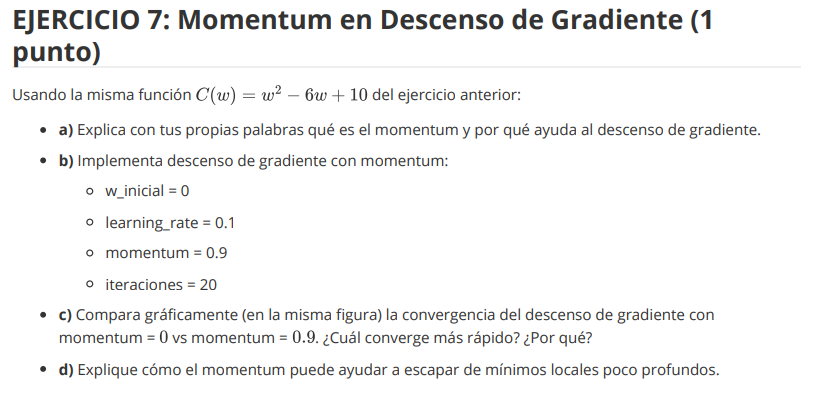


 
A) Explica con tus propias palabras qué es el momentum y por qué ayuda al descenso de gradiente.
 
El momentum es una técnica del descenso de gradiente que acumula parte del movimiento anterior, tal y como la inercia y la gravedad.
En lugar de depender solo de una gradiente, combina la dirección anterior con una nueva.
Esto hace que se acelere la convergencia en direcciones consistentes, y ayuda a reducir las oscilaciones y permite escapar de mínimos locales poco profundos.
En resumen, el momentum hace que el algoritmo se mueva de forma más estable y eficiente hacia el punto de menor costo.
De esta manera, mantiene una dirección estable, reduce zig-zag en valles alargados y acelera la convergencia.
 
B) Implementa descenso de gradiente con momentum.
 
Función de costo: w**2 - 6*w + 10
Derivada: 2*w - 6
Parámetros: w_inicial=0.0, learning_rate=0.1, momentum=0.9, iteraciones=20
 
C) Compara gráficamente (en la misma figura) la convergencia con momentum=0 y momentum=0.9.
 


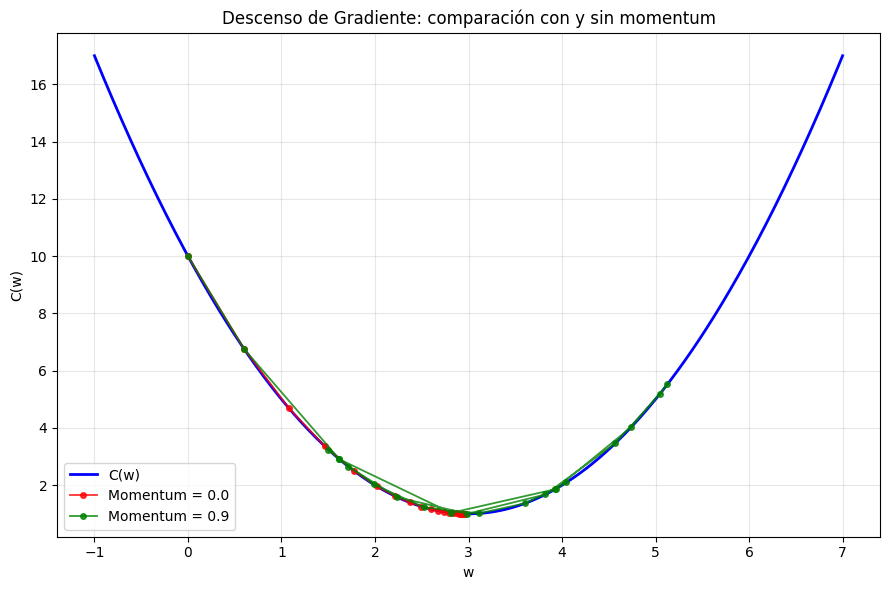

 
Explicación: 
  Momentum=0.9 (el verde) converge en menos iteraciones y con menor zig-zag que momentum=0.0 (rojo),
  porque la inercia acumula dirección útil y amortigua oscilaciones.
 
 
D) Explique cómo el momentum puede ayudar a escapar de mínimos locales poco profundos. 
 
Al conservar velocidad de pasos previos, el momentum puede superar pequeños 'bordes' de mínimos locales,
continuando la marcha hacia regiones de menor costo y favoreciendo alcanzar el mínimo global.


In [109]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Función del ejercicio: C(w) = w^2 - 6w + 10

w = sp.Symbol('w', real=True)
C_sym = w**2 - 6*w + 10
C_prime_sym = sp.diff(C_sym, w)
C = sp.lambdify(w, C_sym)
grad_C = sp.lambdify(w, C_prime_sym)
C = sp.lambdify(w, C_sym)
grad_C = sp.lambdify(w, C_prime_sym)

# A) Explica con tus propias palabras qué es el momentum y por qué ayuda al descenso de gradiente.

print(" ")
print("A) Explica con tus propias palabras qué es el momentum y por qué ayuda al descenso de gradiente.")
print(" ")
print("El momentum es una técnica del descenso de gradiente que acumula parte del movimiento anterior, tal y como la inercia y la gravedad.")
print("En lugar de depender solo de una gradiente, combina la dirección anterior con una nueva.")
print("Esto hace que se acelere la convergencia en direcciones consistentes, y ayuda a reducir las oscilaciones y permite escapar de mínimos locales poco profundos.")
print("En resumen, el momentum hace que el algoritmo se mueva de forma más estable y eficiente hacia el punto de menor costo.")
print("De esta manera, mantiene una dirección estable, reduce zig-zag en valles alargados y acelera la convergencia.")


# B) Implementa descenso de gradiente con momentum.
# w_inicial = 0, learning_rate = 0.1, momentum = 0.9, iteraciones = 20


print(" ")
print("B) Implementa descenso de gradiente con momentum.")
print(" ")

def momentumgradiente(w_inicial, learning_rate, momentum, iteraciones):
    w_actual = float(w_inicial)
    v = 0.0
    trayectoria = [w_actual]
    for i in range(iteraciones):
        grad = grad_C(w_actual)
        v = momentum * v - learning_rate * grad
        w_actual = w_actual + v
        trayectoria.append(w_actual)
    return np.array(trayectoria, dtype=float)

# Parámetros solicitados
w_inicial = 0.0
learning_rate = 0.1
iteraciones = 20

tray_09 = momentumgradiente(w_inicial, learning_rate, 0.9, iteraciones)

print("Función de costo:", C_sym)
print("Derivada:", C_prime_sym)
print(f"Parámetros: w_inicial={w_inicial}, learning_rate={learning_rate}, momentum=0.9, iteraciones={iteraciones}")

# C) Compara gráficamente (en la misma figura) momentum=0 vs momentum=0.9

print(" ")
print("C) Compara gráficamente (en la misma figura) la convergencia con momentum=0 y momentum=0.9.")
print(" ")

tray_00 = momentumgradiente(w_inicial, learning_rate, 0.0, iteraciones)
w_vals = np.linspace(-1, 7, 500)
C_vals = C(w_vals)
plt.figure(figsize=(9,6))
plt.plot(w_vals, C_vals, 'b-', linewidth=2.0, label='C(w)')
plt.plot(tray_00, C(tray_00), 'ro-', linewidth=1.3, markersize=4, alpha=0.8, label='Momentum = 0.0')
plt.plot(tray_09, C(tray_09), 'go-', linewidth=1.3, markersize=4, alpha=0.8, label='Momentum = 0.9')
plt.title('Descenso de Gradiente: comparación con y sin momentum')
plt.xlabel('w')
plt.ylabel('C(w)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print(" ")
print("Explicación: ")
print("  Momentum=0.9 (el verde) converge en menos iteraciones y con menor zig-zag que momentum=0.0 (rojo),")
print("  porque la inercia acumula dirección útil y amortigua oscilaciones.")
print(" ")


# D) Explique cómo el momentum puede ayudar a escapar de mínimos locales poco profundos.
print(" ")
print("D) Explique cómo el momentum puede ayudar a escapar de mínimos locales poco profundos. ")
print(" ")
print("Al conservar velocidad de pasos previos, el momentum puede superar pequeños 'bordes' de mínimos locales,")
print("continuando la marcha hacia regiones de menor costo y favoreciendo alcanzar el mínimo global.")

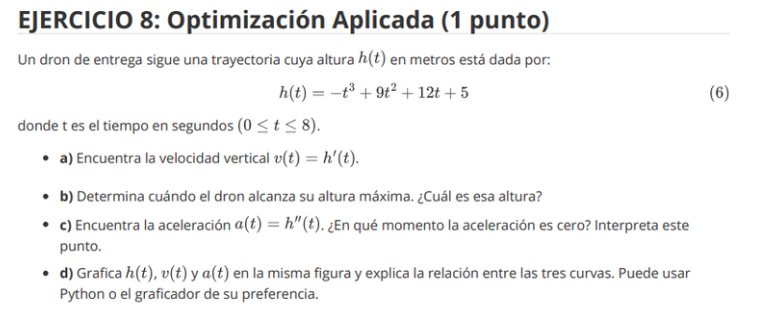



 
A) Encuentra la velocidad vertical v(t) = h'(t).
 
h(t) = -t**3 + 9*t**2 + 12*t + 5
v(t) = h'(t) = -3*t**2 + 18*t + 12  
 
B) Determina cuándo el dron alcanza su altura máxima. ¿Cuál es esa altura?

 
Crítico en t = 6.605551 s con a(t)<0 -> máximo local.
Altura máxima en el intervalo [0,8]: t* = 6.605551 s,  h(t*) = 188.744333 m.

 
C) Encuentra la aceleración a(t) = h''(t). ¿En qué momento la aceleración es cero? Interprétalo.

 
a(t) = h''(t) = 18 - 6*t
Instantes con a(t)=0 en [0,8]: [3.0]
Interpretación: donde a(t)=0 cambia la concavidad de h(t) -> cambio en la tendencia de la velocidad.

 
D) Gráfica de h(t), v(t) y a(t) en la misma figura.

 


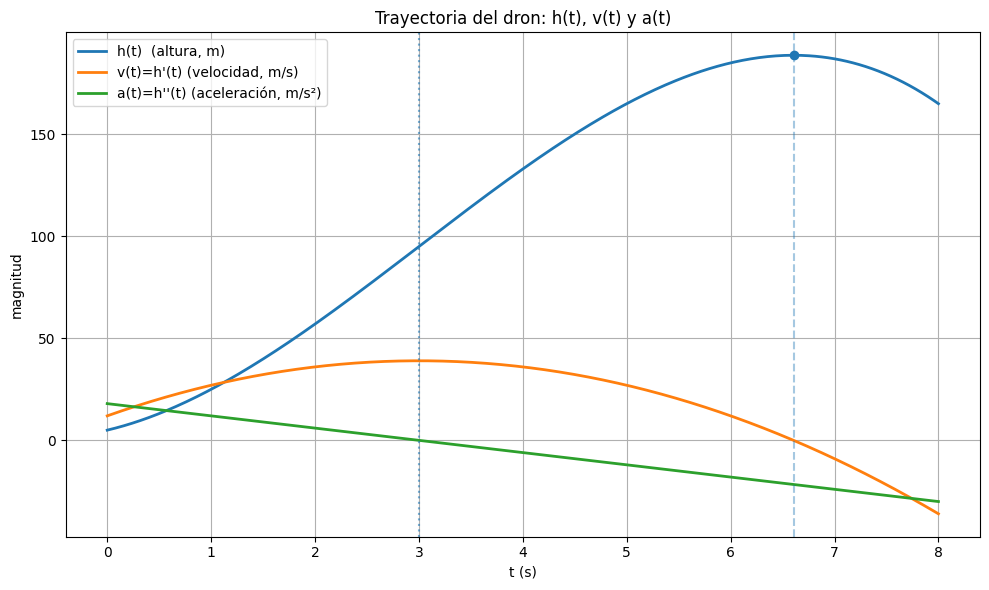

 
Relación entre curvas:
- v(t) es la pendiente de h(t): donde v(t)=0, h(t) alcanza extremum (máximo/mínimo).
- a(t) es la pendiente de v(t) y la concavidad de h(t): a(t)=0 indica cambio de concavidad.


In [110]:
# h(t) = -t^3 + 9t^2 + 12t + 5 ,  0 <= t <= 8

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt


t = sp.Symbol('t', real=True)
h = -t**3 + 9*t**2 + 12*t + 5
v = sp.diff(h, t)        # h'(t)
a = sp.diff(v, t)        # h''(t)
h_fn = sp.lambdify(t, h)
v_fn = sp.lambdify(t, v)
a_fn = sp.lambdify(t, a)
t_min, t_max_dom = 0.0, 8.0
T = np.linspace(t_min, t_max_dom, 400)

# A) Encuentra la velocidad vertical v(t) = h'(t).
print(" ")
print("A) Encuentra la velocidad vertical v(t) = h'(t).")
print(" ")
print("h(t) =", h)
print("v(t) = h'(t) =", v," ")


# B) Determina cuándo el dron alcanza su altura máxima. ¿Cuál es esa altura?
print(" ")
print("B) Determina cuándo el dron alcanza su altura máxima. ¿Cuál es esa altura?\n")
print(" ")

# Máximo local: v(t)=0 y a(t)<0 dentro del dominio [0,8]
criticos = [c for c in sp.solve(sp.Eq(v, 0), t) if c.is_real]
criticos_en_rango = [c for c in criticos if float(c) >= t_min and float(c) <= t_max_dom]

t_max_altura = None
for c in criticos_en_rango:
    if a.subs(t, c) < 0:   # prueba de 2da derivada
        t_max_altura = float(c)
candidatos = [t_min, t_max_dom] + ([t_max_altura] if t_max_altura is not None else []) # revisar extremos del intervalo por si fueran máximos
valores = [(ti, float(h_fn(ti))) for ti in candidatos]

# Elegir el mayor
ti_opt, h_opt = max(valores, key=lambda z: z[1])

if t_max_altura is not None:
    print(f"Crítico en t = {t_max_altura:.6f} s con a(t)<0 -> máximo local.")
else:
    print("No hay crítico con a(t)<0 dentro de [0,8]; se evalúan extremos del intervalo.")

print(f"Altura máxima en el intervalo [0,8]: t* = {ti_opt:.6f} s,  h(t*) = {h_opt:.6f} m.\n")

# C) Encuentra la aceleración a(t) = h''(t). ¿En qué momento la aceleración es cero? Interprétalo.

print(" ")
print("C) Encuentra la aceleración a(t) = h''(t). ¿En qué momento la aceleración es cero? Interprétalo.\n")
print(" ")
print("a(t) = h''(t) =", a)
raices_a = [r for r in sp.solve(sp.Eq(a, 0), t) if r.is_real]
raices_a_en_rango = [float(r) for r in raices_a if float(r) >= t_min and float(r) <= t_max_dom]
print("Instantes con a(t)=0 en [0,8]:", raices_a_en_rango)

if raices_a_en_rango:
    print("Interpretación: donde a(t)=0 cambia la concavidad de h(t) -> cambio en la tendencia de la velocidad.\n")
else:
    print("Interpretación: si no hay a(t)=0 en [0,8], no hay cambio de concavidad en ese intervalo.\n")


# D) Grafica h(t), v(t) y a(t) en la misma figura y explica la relación

print(" ")
print("D) Gráfica de h(t), v(t) y a(t) en la misma figura.\n")
print(" ")
plt.figure(figsize=(10,6))
plt.plot(T, h_fn(T), label="h(t)  (altura, m)", linewidth=2)
plt.plot(T, v_fn(T), label="v(t)=h'(t) (velocidad, m/s)", linewidth=2)
plt.plot(T, a_fn(T), label="a(t)=h''(t) (aceleración, m/s²)", linewidth=2)
plt.scatter([ti_opt], [h_fn(ti_opt)], zorder=5)
ceros_v = [float(c) for c in sp.solve(sp.Eq(v, 0), t) if float(c) >= t_min and float(c) <= t_max_dom]
for cv in ceros_v:
    plt.axvline(cv, linestyle='--', alpha=0.4)
for ca in raices_a_en_rango:
    plt.axvline(ca, linestyle=':', alpha=0.6)
plt.title("Trayectoria del dron: h(t), v(t) y a(t)")
plt.xlabel("t (s)")
plt.ylabel("magnitud")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
print(" ")
print("Relación entre curvas:")
print("- v(t) es la pendiente de h(t): donde v(t)=0, h(t) alcanza extremum (máximo/mínimo).")
print("- a(t) es la pendiente de v(t) y la concavidad de h(t): a(t)=0 indica cambio de concavidad.")

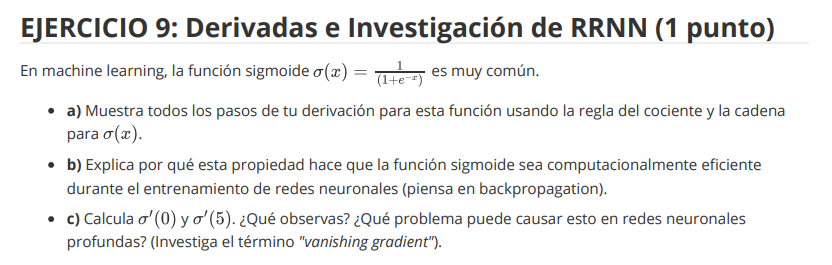

 
A) Muestra todos los pasos de tu derivación para esta función usando la regla del cociente y la cadena para σ(x).
 
 
Definición: σ(x) = 1 / (1 + e^{-x})
 
Sea u(x)=1 y v(x)=1+e^{-x}. Entonces σ(x) = u(x)/v(x).
u'(x)=0. v'(x) = d/dx[1+e^{-x}] = -e^{-x}.
 
Por la regla del cociente:
 
  σ'(x) = (u'(x)v(x) - u(x)v'(x)) / v(x)^2
        = (0*(1+e^{-x}) - 1*(-e^{-x})) / (1+e^{-x})^2
        = e^{-x} / (1+e^{-x})^2.
Ahora, observa que σ(x) = 1/(1+e^{-x}) y 1-σ(x) = e^{-x}/(1+e^{-x}).
 
Por lo tanto: σ'(x) = σ(x) * (1 - σ(x)).
 
Verificación con las definiciones de variables hechas con sympy:
 
σ'(x) (forma directa)         = exp(-x)/(1 + exp(-x))**2
σ'(x) (forma simplificada)    = 1/(4*cosh(x/2)**2)
 
B) Explica por qué esta propiedad hace que la función sigmoide sea computacionalmente eficiente durante el entrenamiento de redes neuronales (piensa en backpropagation).
 
En backpropagation, ya se tiene a = σ(z) calculado en la pasada hacia adelante.
La identidad σ'(z) = a * (1 - a) permite

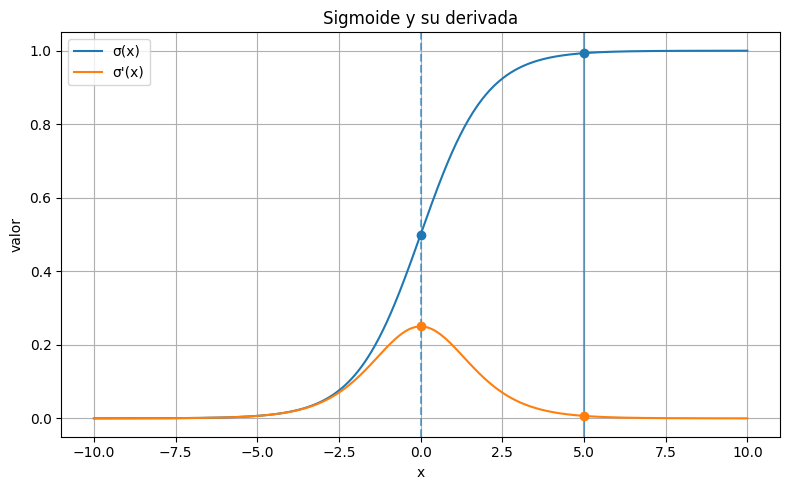

In [111]:
# backpropagation, funcion sigmoide que no hemos visto en clase, investigar en youtube:

# https://youtu.be/iOsR-EC9z6I?si=pl2f3Ma0aImkeXjQ

# https://youtu.be/_0wdproot34?si=MdfTi6mqQEXJ7Pl_ (ejemplos)

# funcion sigmoide: σ(x) = 1 / (1 + e^{-x})

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt


x = sp.symbols('x', real=True)
sigmoide = 1 / (1 + sp.exp(-x))          # σ(x)
sigmoide_derivada = sp.diff(sigmoide, x)       # σ'(x)
sigmoide_derivada_simplificada = sp.simplify(sigmoide_derivada)
funcion_sigmoide = sp.lambdify(x, sigmoide)
funcion_sigmoide_derivada = sp.lambdify(x, sigmoide_derivada_simplificada)


# A) Muestra todos los pasos de tu derivación para esta función usando la regla del cociente y la cadena para σ(x).
print(" ")
print("A) Muestra todos los pasos de tu derivación para esta función usando la regla del cociente y la cadena para σ(x).")
print(" ")

print(" ")

print("Definición: σ(x) = 1 / (1 + e^{-x})")

print(" ")


print("Sea u(x)=1 y v(x)=1+e^{-x}. Entonces σ(x) = u(x)/v(x).")
print("u'(x)=0. v'(x) = d/dx[1+e^{-x}] = -e^{-x}.")

print(" ")
print("Por la regla del cociente:")
print(" ")

print("  σ'(x) = (u'(x)v(x) - u(x)v'(x)) / v(x)^2")
print("        = (0*(1+e^{-x}) - 1*(-e^{-x})) / (1+e^{-x})^2")
print("        = e^{-x} / (1+e^{-x})^2.")
print("Ahora, observa que σ(x) = 1/(1+e^{-x}) y 1-σ(x) = e^{-x}/(1+e^{-x}).")

print(" ")
print("Por lo tanto: σ'(x) = σ(x) * (1 - σ(x)).")
print(" ")
print("Verificación con las definiciones de variables hechas con sympy:")
print(" ")
print("σ'(x) (forma directa)         =", sigmoide_derivada)
print("σ'(x) (forma simplificada)    =", sigmoide_derivada_simplificada)


# B) Explica por qué esta propiedad hace que la función sigmoide sea computacionalmente eficiente durante el entrenamiento de redes neuronales (piensa en backpropagation).
print(" ")
print("B) Explica por qué esta propiedad hace que la función sigmoide sea computacionalmente eficiente durante el entrenamiento de redes neuronales (piensa en backpropagation).")
print(" ")

print("En backpropagation, ya se tiene a = σ(z) calculado en la pasada hacia adelante.")
print("La identidad σ'(z) = a * (1 - a) permite obtener la derivada usando solo a (multiplicaciones/restas),")
print("sin recalcular exponentes. Esto reduce costo y simplifica el cómputo del gradiente a nivel de neurona.")

# Demostración mínima de backprop en una neurona logística (MSE como ejemplo)
print("Demostración mínima de backprop en una neurona:")
print("z = w*x + b,  a = σ(z),  L = 0.5*(a - y)^2  ⇒ dL/dz = (a - y) * a * (1 - a)")

# Valores de ejemplo
peso, sesgo, entrada, objetivo = 0.7, -0.2, 2.0, 1.0
z_valor = peso * entrada + sesgo
activacion = funcion_sigmoide(z_valor)
dL_dz = (activacion - objetivo) * activacion * (1 - activacion)   # usando σ'(z)=a(1-a)
dL_dw = dL_dz * entrada
dL_db = dL_dz

print(f"Ejemplo numérico: w={peso}, b={sesgo}, x={entrada}, y={objetivo}")
print(f"a=σ(z)={activacion:.6f},  dL/dz={(dL_dz):.6f},  dL/dw={dL_dw:.6f},  dL/db={dL_db:.6f}")


# C) Calcula σ′(0) y σ′(5). ¿Qué observas? ¿Qué problema puede causar esto en redes neuronales profundas? (Investiga el término 'vanishing gradient').

print(" ")
print("C) Calcula σ′(0) y σ′(5). ¿Qué observas? ¿Qué problema puede causar esto en redes neuronales profundas? (Investiga el término 'vanishing gradient').")
print(" ")

sigmoide_derivada_0 = float(funcion_sigmoide_derivada(0.0))
sigmoide_derivada_5 = float(funcion_sigmoide_derivada(5.0))
sigmoide_0 = float(funcion_sigmoide(0.0))
sigmoide_5 = float(funcion_sigmoide(5.0))

print(" ")
print(f"σ(0) = {sigmoide_0:.6f}  -> σ'(0) = {sigmoide_derivada_0:.6f}")
print(f"σ(5) = {sigmoide_5:.6f}  ->  σ'(5) = {sigmoide_derivada_5:.6f}")

print(" ")
print(" ")

print("Observación:")
print("σ'(x) alcanza su máximo en x≈0 (valor 0.25) y se hace muy pequeña para x grandes (saturación).")
print("En redes profundas, esto causa 'vanishing gradient': los gradientes se atenúan capa tras capa,")
print("dificultando el aprendizaje de capas tempranas y ralentizando o impidiendo la convergencia.")


valores_x = np.linspace(-10, 10, 800)
plt.figure(figsize=(8,5))
plt.plot(valores_x, funcion_sigmoide(valores_x),  label="σ(x)")
plt.plot(valores_x, funcion_sigmoide_derivada(valores_x), label="σ'(x)")
plt.scatter([0,5], [funcion_sigmoide(0), funcion_sigmoide(5)],  zorder=5)
plt.scatter([0,5], [funcion_sigmoide_derivada(0), funcion_sigmoide_derivada(5)], zorder=5)
plt.axvline(0, linestyle='--', alpha=0.6)
plt.axvline(5, alpha=0.6)
plt.title("Sigmoide y su derivada")
plt.xlabel("x"); plt.ylabel("valor")
plt.grid(True); plt.legend(); plt.tight_layout()



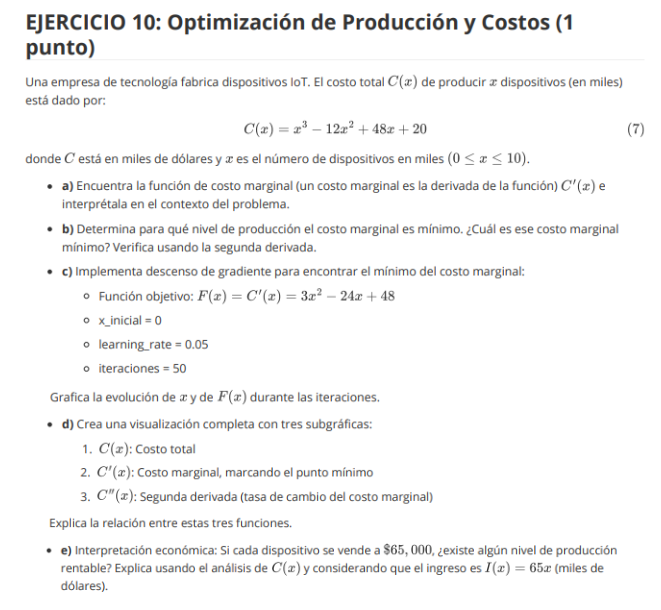


 
A)  Encuentra la función de costo marginal C'(x)
 
Costo total:  C(x) = x**3 - 12*x**2 + 48*x + 20
Costo marginal: C'(x) = 3*x**2 - 24*x + 48
Interpretación: C'(x) representa el costo adicional (en dólares)
que implica producir una unidad más de dispositivos (en unidades lineales). 
 
B)  Determina para qué nivel de producción el costo marginal es mínimo 
 
C''(x) =  6*x - 24
Punto crítico del costo marginal:  [4]
x = 4.00  ->  C'''(x) = 0.00 -> máximo
Por lo tanto, el costo marginal es mínimo en x = 4.00
 
C) Descenso de gradiente para encontrar el mínimo del costo marginal.
 


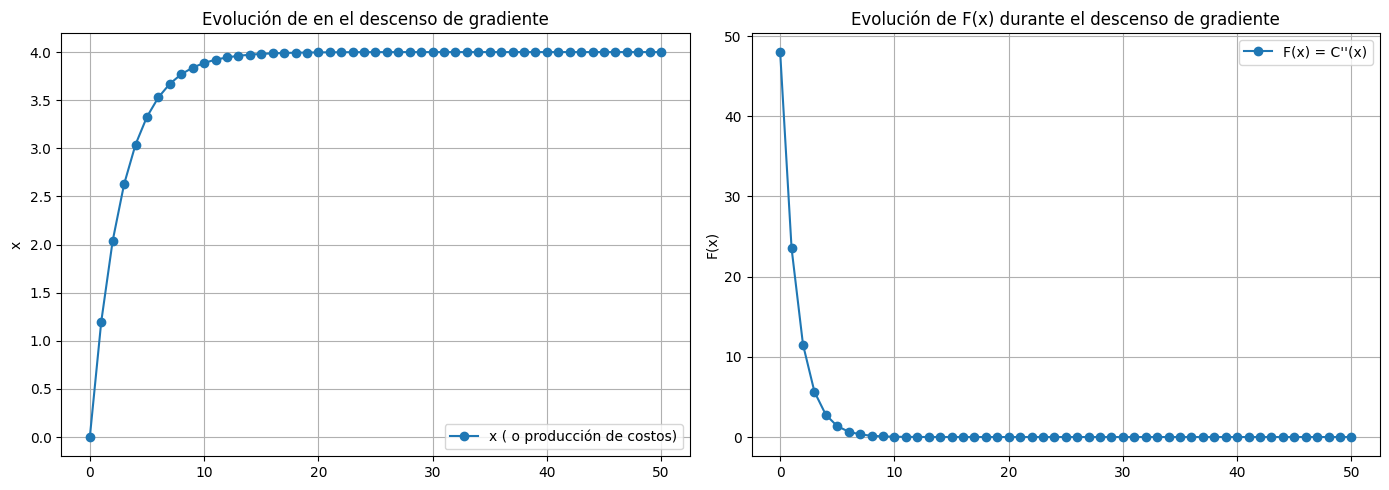

x final = 4.0000
F(x_final) = 0.0000
Coincide con el mínimo del costo.
 
D) Visualización completa con las tres subgráficas: 
 


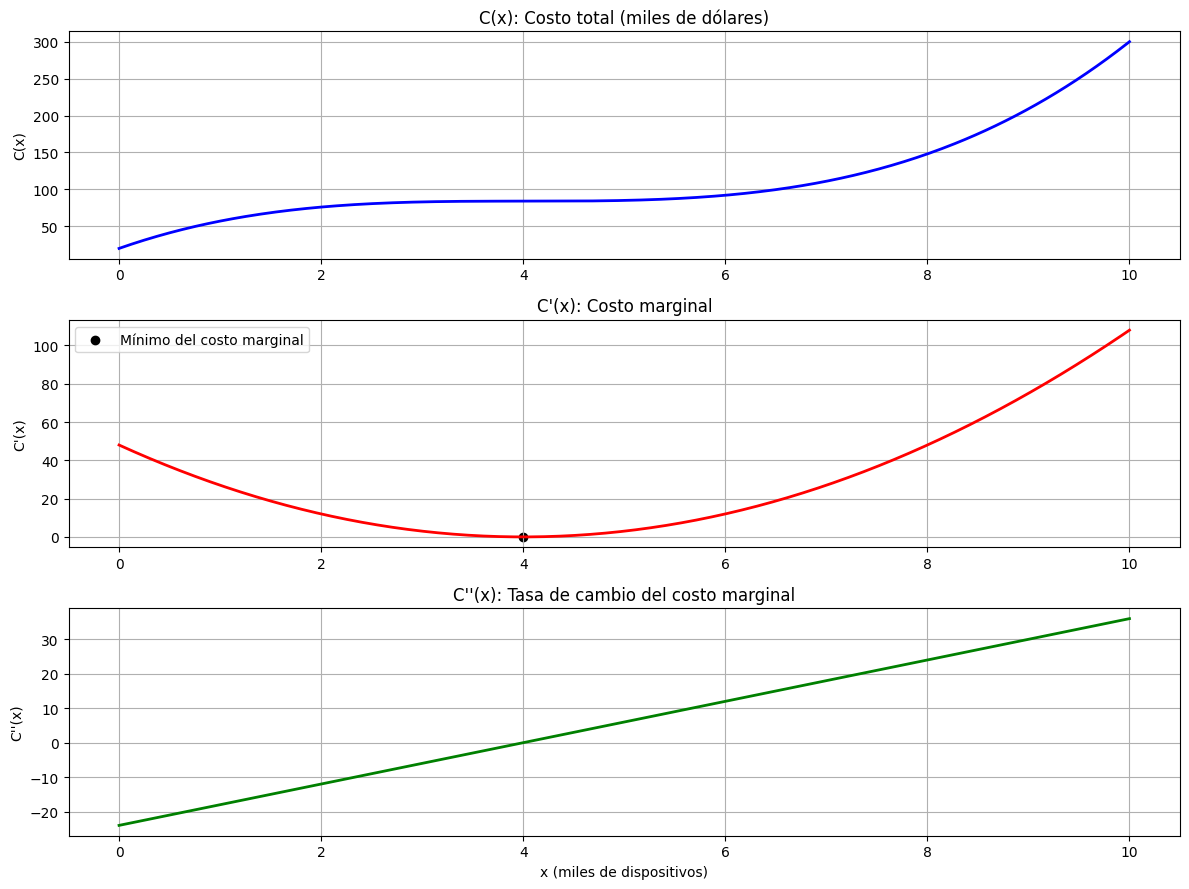

 
Relación entre funciones:
- C'(x) es la pendiente de C(x), y C''(x) describe cómo cambia esa pendiente.
- El punto donde C''(x)=0 marca el cambio de curvatura en el costo marginal.

 
E) Interpretación económica: 
 
Beneficio máximo analítico en x = [8.654746681256313]
Nivel de producción óptimo ≈ -0.65 mil dispositivos
Ingreso I(x) = -42.56,  Costo C(x) = -16.85,  Beneficio = -25.71 (miles de dólares)
 
Conclusión: 
- El beneficio máximo ocurre cuando el ingreso marginal ≈ costo marginal.
- Si el precio de venta es fijo (65 mil USD/unidad), la empresa es rentable mientras I(x) > C(x).
- Más allá del punto óptimo, producir más aumenta el costo más rápido que el ingreso, reduciendo utilidad.


In [120]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

x = sp.Symbol('x', real=True)
C = x**3 - 12*x**2 + 48*x + 20
C_prime = sp.diff(C, x)       # C'(x): costo marginal
C_double = sp.diff(C_prime, x) # C''(x): segunda derivada (tasa de cambio del costo marginal)
C_f = sp.lambdify(x, C)
C_p = sp.lambdify(x, C_prime)
C_pp = sp.lambdify(x, C_double)

# a) Encuentra la funcion de costo marginal C'(x)

print(" ")
print("A)  Encuentra la función de costo marginal C'(x)")
print(" ")


print("Costo total:  C(x) =", C)
print("Costo marginal: C'(x) =", C_prime)
print("Interpretación: C'(x) representa el costo adicional (en dólares)")
print("que implica producir una unidad más de dispositivos (en unidades lineales). ")

# b) Determina para qué nivel de producción el costo marginal es mínimo

print(" ")
print("B)  Determina para qué nivel de producción el costo marginal es mínimo ")
print(" ")

C_prime_min = sp.diff(C_prime, x)
crit_points = sp.solve(C_prime_min, x)
print("C''(x) = ", C_double)
print("Punto crítico del costo marginal: ", crit_points)
for p in crit_points:
    test = C_pp(p)
    tipo = "mínimo" if test > 0 else "máximo"
    print(f"x = {float(p):.2f}  ->  C'''(x) = {float(test):.2f} -> {tipo}")

print(f"Por lo tanto, el costo marginal es mínimo en x = {float(crit_points[0]):.2f}")


# c) Descenso de gradiente para minimizar C'(x)
#    F(x) = C''(x) = 3x² - 24x + 48


print(" ")
print("C) Descenso de gradiente para encontrar el mínimo del costo marginal.")
print(" ")

F_sym = 3*x**2 - 24*x + 48
F_prime_sym = sp.diff(F_sym, x)
F = sp.lambdify(x, F_sym)
F_prime = sp.lambdify(x, F_prime_sym)

def gradient_descent(x_inicial, learning_rate, iteraciones):
    x_actual = x_inicial
    trayectoria = [x_actual]
    for i in range(iteraciones):
        grad = F_prime(x_actual)
        x_actual = x_actual - learning_rate * grad
        trayectoria.append(x_actual)
        if abs(x_actual) > 50:
            print(f"x salió de rango en la iteración {i}")
            break
    return np.array(trayectoria)
x_inicial = 0
learning_rate = 0.05
iteraciones = 50

tray = gradient_descent(x_inicial, learning_rate, iteraciones)

# Gráfica evolución y la funcion F(x)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Evolución de x
axes[0].plot(tray, 'o-', label='x ( o producción de costos)')
axes[0].set_title('Evolución de en el descenso de gradiente')
axes[0].set_ylabel('x')
axes[0].grid(True)
axes[0].legend()
axes[1].plot(F(tray), 'o-', label='F(x) = C\'\'(x)')
axes[1].set_title('Evolución de F(x) durante el descenso de gradiente')
axes[1].set_ylabel('F(x)')
axes[1].grid(True)
axes[1].legend()
plt.tight_layout()
plt.show()
print(f"x final = {tray[-1]:.4f}")
print(f"F(x_final) = {F(tray[-1]):.4f}")
print("Coincide con el mínimo del costo.")


# d) Visualización con tres subgráficas

print(" ")
print("D) Visualización completa con las tres subgráficas: ")
print(" ")
x_vals = np.linspace(0, 10, 400)
plt.figure(figsize=(12,9))
plt.subplot(3,1,1)
plt.plot(x_vals, C_f(x_vals), 'b', linewidth=2)
plt.title('C(x): Costo total (miles de dólares)')
plt.ylabel('C(x)')
plt.grid(True)
plt.subplot(3,1,2)
plt.plot(x_vals, C_p(x_vals), 'r', linewidth=2)
min_x = float(crit_points[0])
plt.scatter([min_x], [C_p(min_x)], color='black', label='Mínimo del costo marginal')
plt.title("C'(x): Costo marginal")
plt.ylabel("C'(x)")
plt.legend(); plt.grid(True)
plt.subplot(3,1,3)
plt.plot(x_vals, C_pp(x_vals), 'g', linewidth=2)
plt.title("C''(x): Tasa de cambio del costo marginal")
plt.xlabel("x (miles de dispositivos)")
plt.ylabel("C''(x)")
plt.grid(True)
plt.tight_layout(); plt.show()
print(" ")
print("Relación entre funciones:")
print("- C'(x) es la pendiente de C(x), y C''(x) describe cómo cambia esa pendiente.")
print("- El punto donde C''(x)=0 marca el cambio de curvatura en el costo marginal.\n")


# e) Interpretación económica

print(" ")
print("E) Interpretación económica: ")
print(" ")

# Ingreso: I(x) = 65x
I = 65*x
I_f = sp.lambdify(x, I)

# Beneficio: B(x) = I(x) - C(x)
B = I - C
B_f = sp.lambdify(x, B)

# Buscar x donde beneficio = 0 y máximo
crit_B = sp.solve(sp.diff(B, x), x)
print("Beneficio máximo analítico en x =", [float(c) for c in crit_B if 0 <= c <= 10])

x_benef_max = float(crit_B[0])
print(f"Nivel de producción óptimo ≈ {x_benef_max:.2f} mil dispositivos")
print(f"Ingreso I(x) = {I_f(x_benef_max):.2f},  Costo C(x) = {C_f(x_benef_max):.2f},  Beneficio = {B_f(x_benef_max):.2f} (miles de dólares)")

print(" ")
print("Conclusión: ")
print("- El beneficio máximo ocurre cuando el ingreso marginal ≈ costo marginal.")
print("- Si el precio de venta es fijo (65 mil USD/unidad), la empresa es rentable mientras I(x) > C(x).")
print("- Más allá del punto óptimo, producir más aumenta el costo más rápido que el ingreso, reduciendo utilidad.")